In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

plt.rcParams["figure.constrained_layout.use"] = True

ValueError: too many values to unpack (expected 3)

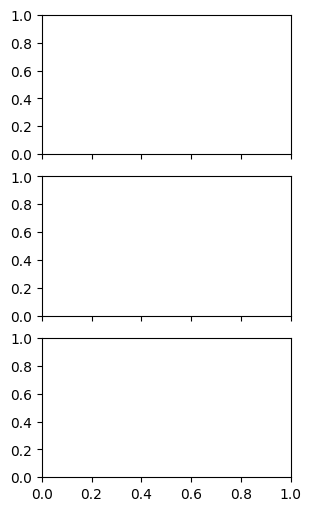

In [2]:
x = np.linspace(-6.0, 6.0, 102)

_, axs = plt.subplots(figsize=(3, 5), nrows=3, sharex=True, sharey=True)

for i, pref, bel in zip(
    range(4),
    [(4.0, 0.5), (0.0, 2.0), (4.0, 0.75)],
    [(3.0, 1.0), (0.5, 1.0), (-1.5, 1.0)],
    [(3.0, 1.0), (0.5, 1.0), (-1.5, 1.0)],
):
    # preferences
    preferences = norm.pdf(x, pref[0], pref[1], pref[2])

    axs[i].fill_between(x, preferences, alpha=0.4, color="#761e58", linewidth=0.0)
    axs[i].plot(x, preferences, color="k", linewidth=0.6)

    # beliefs
    preferences = norm.pdf(x, bel[0], bel[1])

    axs[i].fill_between(x, preferences, alpha=0.4, color="#234c80", linewidth=0.3)
    axs[i].plot(x, preferences, color="k", linewidth=0.6)

    axs[i].yaxis.set_visible(False)
    axs[i].spines["left"].set_visible(False)

sns.despine(left=True)
plt.savefig(Path().cwd().parent / "figures" / "fig_1_distributions.svg")

In [ ]:
def kl_divergence_gaussian(mu1, sigma1, mu2, sigma2):
    """Compute the KL divergence between two univariate Gaussian distributions."""
    ratio = sigma2 / sigma1
    return np.log(ratio) + (sigma1**2 + (mu1 - mu2) ** 2) / (2 * sigma2**2) - 0.5

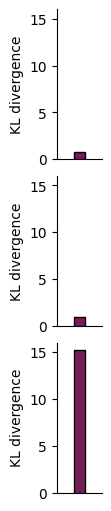

In [ ]:
_, axs = plt.subplots(figsize=(1, 5), nrows=3, sharex=True, sharey=True)

for i, pref, bel in zip(
    range(3),
    [(4.0, 0.5), (0.0, 2.0), (4.0, 0.75)],
    [(3.0, 1.0), (0.5, 1.0), (-1.5, 1.0)],
):
    axs[i].bar(
        0,
        kl_divergence_gaussian(mu1=pref[0], sigma1=pref[1], mu2=bel[0], sigma2=bel[1]),
        color="#761e58",
        width=0.5,
        edgecolor="black",
    )

    axs[i].set_xticks([])
    axs[i].set_xticklabels([])
    axs[i].set(ylim=(0, 16), xlim=(-1, 1), ylabel="KL divergence")

sns.despine()
plt.savefig(Path().cwd().parent / "figures" / "fig_1_kl_divergences.svg")

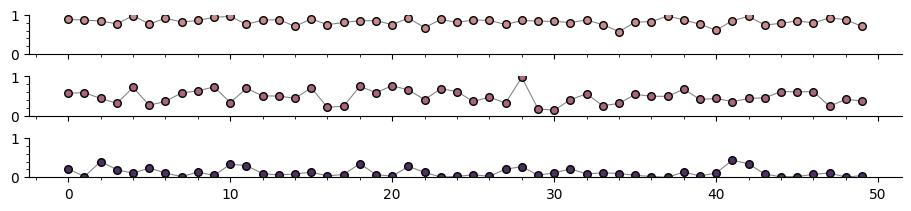

In [ ]:
np.random.seed(42)

time_steps = np.arange(50)
n_nodes = 3

obs_nodes = [
    np.random.beta(a=10, b=2, size=50),
    np.random.beta(a=3, b=3, size=50),
    np.random.beta(a=1, b=8, size=50),
]

fig, axs = plt.subplots(
    n_nodes, 1, figsize=(9, 2), sharex=True, sharey=True, layout="constrained"
)

for i, color in zip(range(n_nodes), ["#c78b8d", "#a86483", "#4d315f"]):
    axs[i].scatter(time_steps, obs_nodes[i], s=30, edgecolor="k", color=color)
    axs[i].plot(time_steps, obs_nodes[i], color="grey", linewidth=0.75, zorder=-1)
    axs[i].set(ylim=(0, 1))
    axs[i].minorticks_on()
sns.despine()
plt.savefig(Path().cwd().parent / "figures" / "fig_1_time_series.svg")

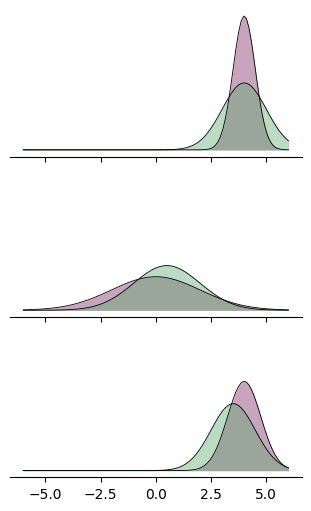

In [ ]:
x = np.linspace(-6.0, 6.0, 102)

_, axs = plt.subplots(figsize=(3, 5), nrows=3, sharex=True, sharey=True)

for i, pref, bel in zip(
    range(3),
    [(4.0, 0.5), (0.0, 2.0), (4.0, 0.75)],
    [(4.0, 1.0), (0.5, 1.5), (3.5, 1.0)],
):
    # preferences
    preferences = norm.pdf(x, pref[0], pref[1])

    axs[i].fill_between(x, preferences, alpha=0.4, color="#761e58", linewidth=0.0)
    axs[i].plot(x, preferences, color="k", linewidth=0.6)

    # beliefs
    preferences = norm.pdf(x, bel[0], bel[1])

    axs[i].fill_between(x, preferences, alpha=0.4, color="#55a868", linewidth=0.3)
    axs[i].plot(x, preferences, color="k", linewidth=0.6)

    axs[i].yaxis.set_visible(False)
    axs[i].spines["left"].set_visible(False)

sns.despine(left=True)
plt.savefig(Path().cwd().parent / "figures" / "fig_1_candidates.svg")

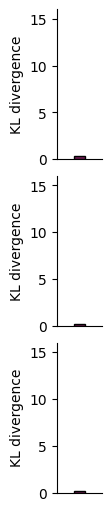

In [ ]:
_, axs = plt.subplots(figsize=(1, 5), nrows=3, sharex=True, sharey=True)

for i, pref, bel in zip(
    range(3),
    [(4.0, 0.5), (0.0, 2.0), (4.0, 0.75)],
    [(4.0, 1.0), (0.5, 1.5), (3.5, 1.0)],
):
    axs[i].bar(
        0,
        kl_divergence_gaussian(mu1=pref[0], sigma1=pref[1], mu2=bel[0], sigma2=bel[1]),
        color="#761e58",
        width=0.5,
        edgecolor="black",
    )

    axs[i].set_xticks([])
    axs[i].set_xticklabels([])
    axs[i].set(ylim=(0, 16), xlim=(-1, 1), ylabel="KL divergence")

sns.despine()
plt.savefig(Path().cwd().parent / "figures" / "fig_1_kl_divergences_candidates.svg")

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_18707/3673044400.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


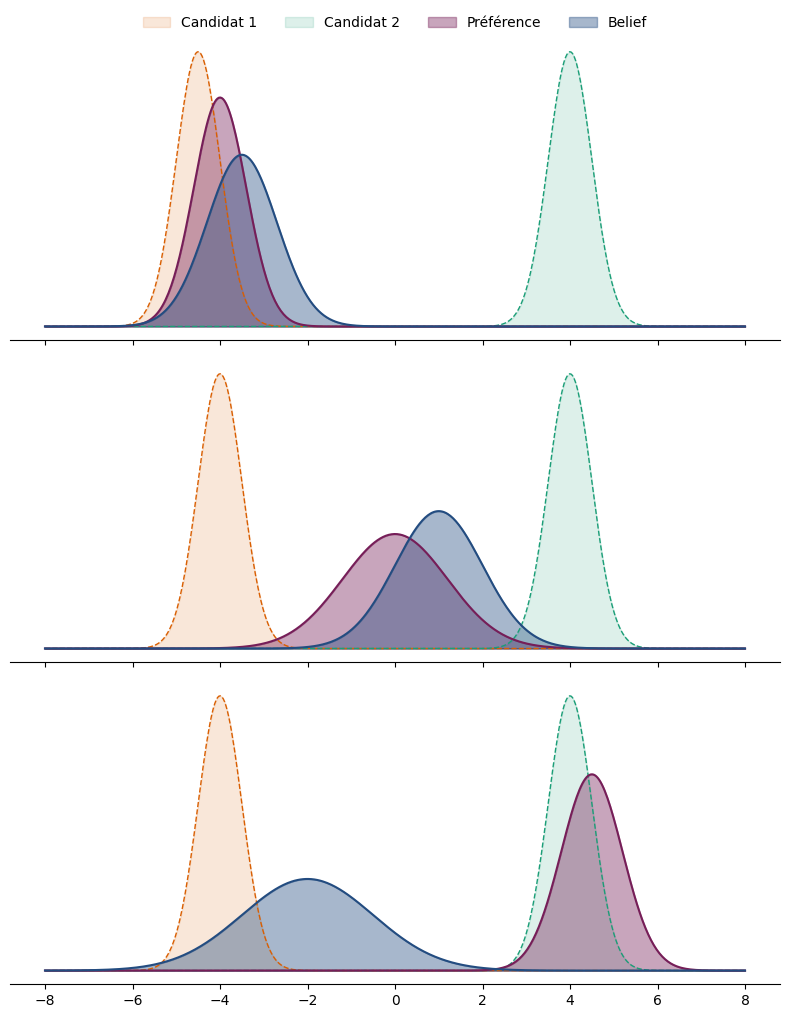

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

# 1. Configuration de l'axe X
x = np.linspace(-8.0, 8.0, 500)

# Couleurs distinctes
color_pref = "#761e58"  # Violet (Ce que je veux)
color_bel = "#234c80"  # Bleu (Ce que je crois)
color_c1 = "#d95f02"  # Orange (Candidat 1)
color_c2 = "#1b9e77"  # Vert (Candidat 2)

# Paramètres (moyenne, écart-type) pour 3 scénarios d'agents
params = [
    # Agent 1 : Aligné avec le Candidat 1
    {"pref": (-4.0, 0.6), "bel": (-3.5, 0.8), "c1": (-4.5, 0.5), "c2": (4.0, 0.5)},
    # Agent 2 : Indécis/Centriste entre les deux
    {"pref": (0.0, 1.2), "bel": (1.0, 1.0), "c1": (-4.0, 0.5), "c2": (4.0, 0.5)},
    # Agent 3 : Dissonance (Préfère C2 mais croit que C1 est "mieux" ou plus fort)
    {"pref": (4.5, 0.7), "bel": (-2.0, 1.5), "c1": (-4.0, 0.5), "c2": (4.0, 0.5)},
]

fig, axs = plt.subplots(figsize=(8, 10), nrows=3, sharex=True, sharey=True)

for i, p in enumerate(params):
    # --- Distributions des Candidats (fixes ou contextuelles) ---
    y_c1 = norm.pdf(x, p["c1"][0], p["c1"][1])
    axs[i].fill_between(
        x, y_c1, alpha=0.15, color=color_c1, label="Candidat 1" if i == 0 else ""
    )
    axs[i].plot(x, y_c1, color=color_c1, linewidth=1, linestyle="--")

    y_c2 = norm.pdf(x, p["c2"][0], p["c2"][1])
    axs[i].fill_between(
        x, y_c2, alpha=0.15, color=color_c2, label="Candidat 2" if i == 0 else ""
    )
    axs[i].plot(x, y_c2, color=color_c2, linewidth=1, linestyle="--")

    # --- Distributions de l'Agent ---
    y_pref = norm.pdf(x, p["pref"][0], p["pref"][1])
    axs[i].fill_between(
        x, y_pref, alpha=0.4, color=color_pref, label="Préférence" if i == 0 else ""
    )
    axs[i].plot(x, y_pref, color=color_pref, linewidth=1.5)

    y_bel = norm.pdf(x, p["bel"][0], p["bel"][1])
    axs[i].fill_between(
        x, y_bel, alpha=0.4, color=color_bel, label="Belief" if i == 0 else ""
    )
    axs[i].plot(x, y_bel, color=color_bel, linewidth=1.5)

    # Esthétique
    axs[i].yaxis.set_visible(False)
    axs[i].spines["left"].set_visible(False)
    axs[i].set_ylabel(f"Agent {i + 1}", rotation=0, labelpad=45, fontweight="bold")

# Légende globale
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)

sns.despine(left=True)
plt.tight_layout()
plt.savefig("agent_cognitive_model.png", bbox_inches="tight")
plt.show()

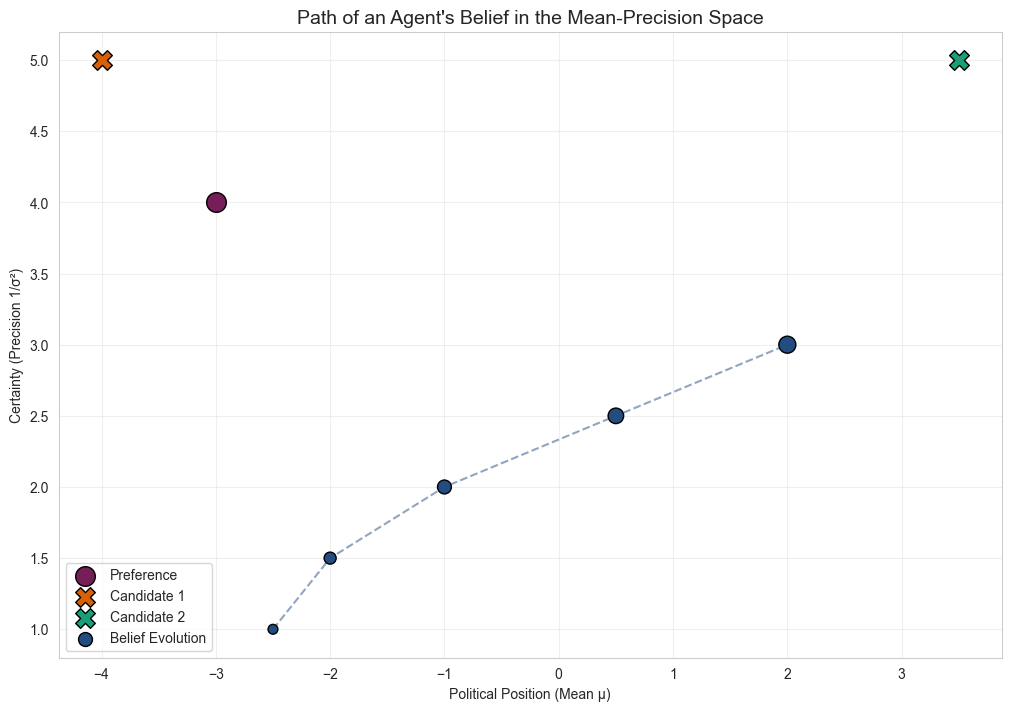

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Données pour un agent
# Format: (mean, precision)
pref = (-3.0, 4.0)  # Ce qu'il veut (très sûr de lui)
cand_1 = (-4.0, 5.0)  # Candidat 1 (Orange)
cand_2 = (3.5, 5.0)  # Candidat 2 (Vert)

# Simulation de l'évolution de la Croyance (Belief) sur 5 étapes
# Elle commence proche de la préférence et dévie selon les observations
beliefs_steps = [(-2.5, 1.0), (-2.0, 1.5), (-1.0, 2.0), (0.5, 2.5), (2.0, 3.0)]

plt.figure(figsize=(10, 7))

# 1. Plot des points fixes (Préférence et Candidats)
plt.scatter(
    pref[0], pref[1], c="#761e58", s=200, label="Preference", edgecolors="k", zorder=5
)
plt.scatter(
    cand_1[0],
    cand_1[1],
    c="#d95f02",
    s=200,
    marker="X",
    label="Candidate 1",
    edgecolors="k",
)
plt.scatter(
    cand_2[0],
    cand_2[1],
    c="#1b9e77",
    s=200,
    marker="X",
    label="Candidate 2",
    edgecolors="k",
)

# 2. Plot de l'évolution de la Croyance (Belief)
means_b = [b[0] for b in beliefs_steps]
precs_b = [b[1] for b in beliefs_steps]

# On dessine une flèche pour montrer le mouvement
plt.plot(means_b, precs_b, color="#234c80", linestyle="--", alpha=0.5, zorder=1)
plt.scatter(
    means_b,
    precs_b,
    c="#234c80",
    s=np.linspace(50, 150, 5),
    label="Belief Evolution",
    edgecolors="k",
)

# Cosmétique
plt.title("Path of an Agent's Belief in the Mean-Precision Space", fontsize=14)
plt.xlabel("Political Position (Mean μ)")
plt.ylabel("Certainty (Precision 1/σ²)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

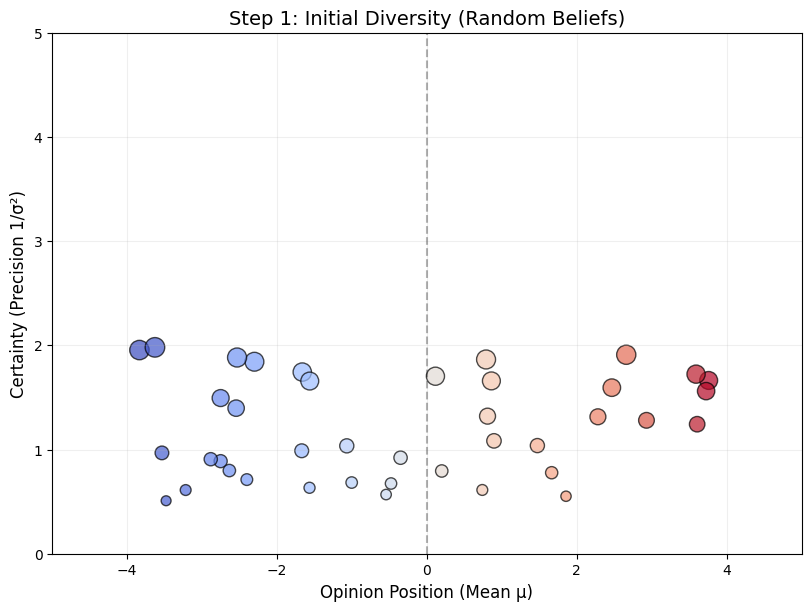

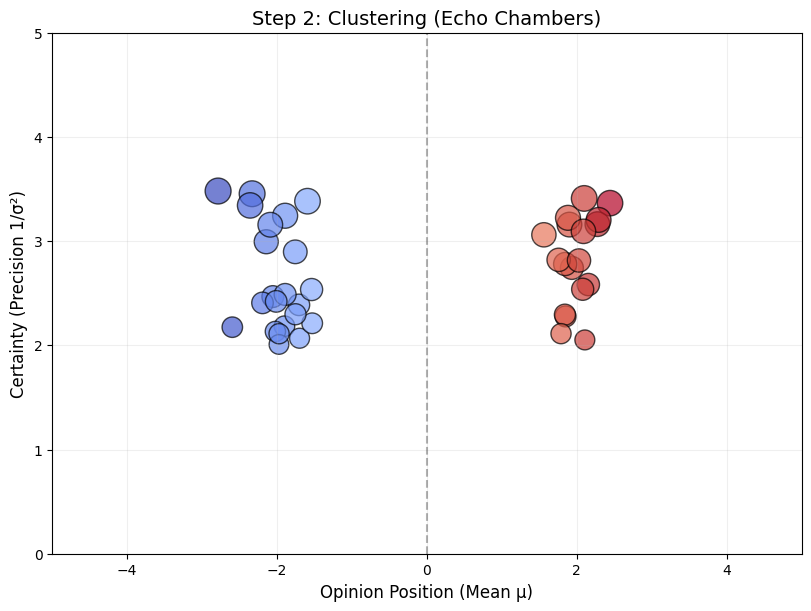

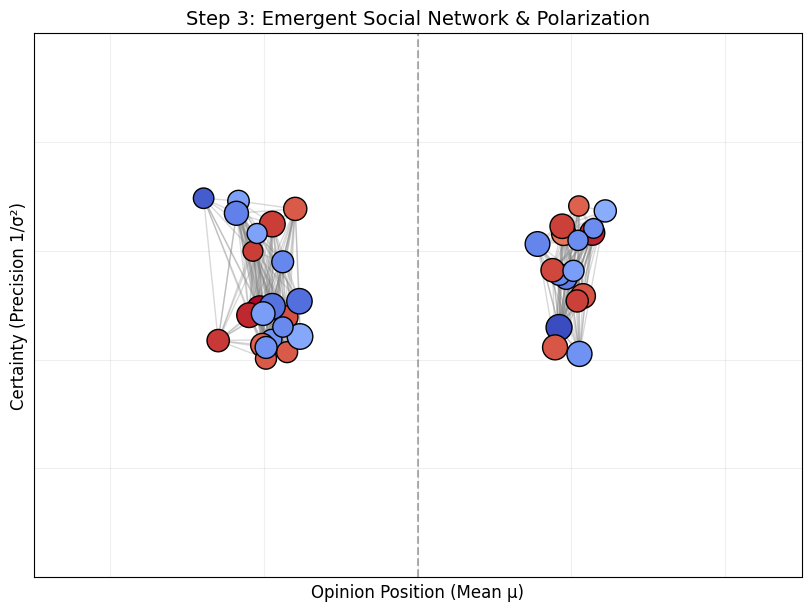

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Initialisation
np.random.seed(42)
n_agents = 40
# X: Position (moyenne), Y: Précision (certitude)
positions = np.random.uniform(-4, 4, n_agents)
precision = np.random.uniform(0.5, 2.0, n_agents)


def plot_step(pos, prec, title, step_type="scatter"):
    """Plot a step in the agent-based model evolution."""
    plt.figure(figsize=(8, 6))

    if step_type == "scatter":
        plt.scatter(
            pos, prec, c=pos, cmap="coolwarm", s=prec * 100, edgecolors="k", alpha=0.7
        )

    elif step_type == "network":
        # On crée un réseau basé sur la proximité des opinions
        G = nx.Graph()
        for i in range(n_agents):
            for j in range(i + 1, n_agents):
                dist = np.abs(pos[i] - pos[j])
                if dist < 0.8:  # Lien si les opinions sont proches
                    G.add_edge(i, j, weight=1 / dist)

        pos_layout = {i: (pos[i], prec[i]) for i in range(n_agents)}
        nx.draw_networkx_edges(G, pos_layout, alpha=0.3, edge_color="gray")
        nx.draw_networkx_nodes(
            G,
            pos_layout,
            node_size=prec * 100,
            node_color=pos,
            cmap="coolwarm",
            edgecolors="k",
        )

    plt.title(title, fontsize=14)
    plt.xlabel("Opinion Position (Mean μ)", fontsize=12)
    plt.ylabel("Certainty (Precision 1/σ²)", fontsize=12)
    plt.axvline(0, color="black", linestyle="--", alpha=0.3)
    plt.xlim(-5, 5)
    plt.ylim(0, 5)
    plt.grid(alpha=0.2)
    plt.show()


# --- ÉTAPE 1 : État Initial (Diversité totale) ---
plot_step(positions, precision, "Step 1: Initial Diversity (Random Beliefs)")

# --- ÉTAPE 2 : Évolution vers des Clusters (Influence sociale) ---
# On simule un regroupement simple
clustered_positions = positions.copy()
clustered_positions[positions < 0] = -2 + np.random.normal(
    0, 0.3, len(positions[positions < 0])
)
clustered_positions[positions >= 0] = 2 + np.random.normal(
    0, 0.3, len(positions[positions >= 0])
)
enhanced_precision = precision + 1.5  # Les agents deviennent plus sûrs d'eux en groupe
plot_step(clustered_positions, enhanced_precision, "Step 2: Clustering (Echo Chambers)")

# --- ÉTAPE 3 : Formation du Réseau (Polarisation) ---
plot_step(
    clustered_positions,
    enhanced_precision,
    "Step 3: Emergent Social Network & Polarization",
    step_type="network",
)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_18707/3529058050.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


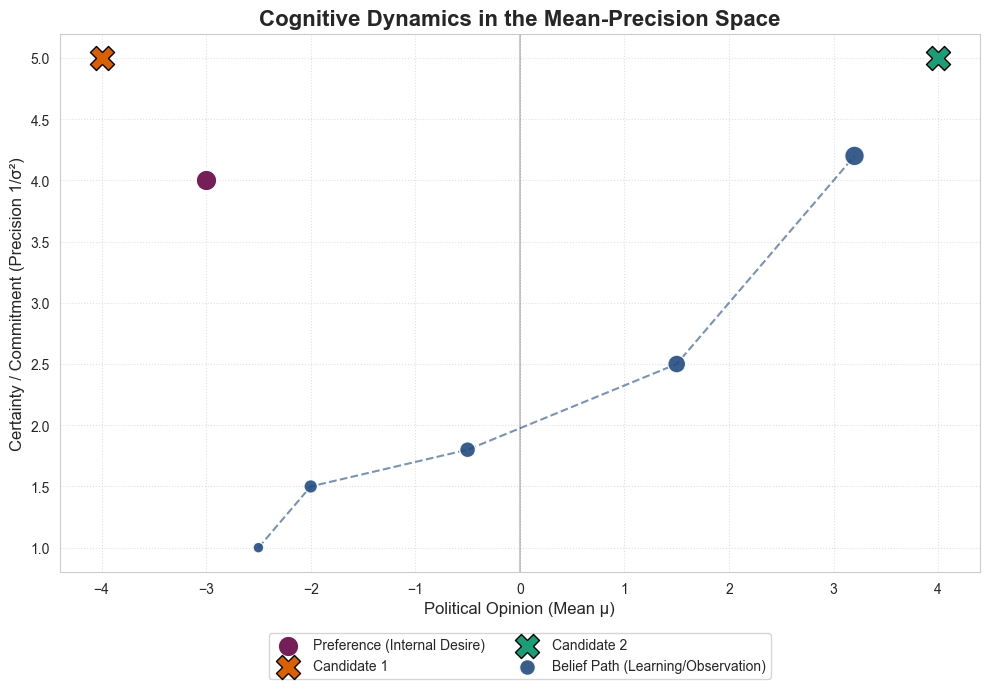

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the Space: Mean (Position) and Precision (Certainty)
plt.figure(figsize=(10, 7))

# Colors
color_pref = "#761e58"  # Purple
color_bel = "#234c80"  # Blue
color_c1 = "#d95f02"  # Orange
color_c2 = "#1b9e77"  # Green

# Data for 1 Agent
pref = (-3.0, 4.0)  # Preference (Static)
c1 = (-4.0, 5.0)  # Candidate 1 (Static Reference)
c2 = (4.0, 5.0)  # Candidate 2 (Static Reference)

# Belief Trajectory (Evolution over time as the agent observes data)
# (Mean moves toward candidate, Precision increases as agent "learns")
beliefs_mu = [-2.5, -2.0, -0.5, 1.5, 3.2]
beliefs_prec = [1.0, 1.5, 1.8, 2.5, 4.2]

# 2. Plotting the Reference Points
plt.scatter(
    pref[0],
    pref[1],
    c=color_pref,
    s=250,
    label="Preference (Internal Desire)",
    edgecolors="white",
    linewidth=2,
    zorder=5,
)
plt.scatter(
    c1[0],
    c1[1],
    c=color_c1,
    s=300,
    marker="X",
    label="Candidate 1",
    edgecolors="k",
    zorder=5,
)
plt.scatter(
    c2[0],
    c2[1],
    c=color_c2,
    s=300,
    marker="X",
    label="Candidate 2",
    edgecolors="k",
    zorder=5,
)

# 3. Plotting the Cognitive Path (Belief Evolution)
plt.plot(beliefs_mu, beliefs_prec, color=color_bel, linestyle="--", alpha=0.6, zorder=1)
plt.scatter(
    beliefs_mu,
    beliefs_prec,
    c=color_bel,
    s=np.linspace(60, 200, 5),
    label="Belief Path (Learning/Observation)",
    edgecolors="white",
    alpha=0.9,
)

# Labels & Aesthetics
plt.title(
    "Cognitive Dynamics in the Mean-Precision Space", fontsize=16, fontweight="bold"
)
plt.xlabel("Political Opinion (Mean μ)", fontsize=12)
plt.ylabel("Certainty / Commitment (Precision 1/σ²)", fontsize=12)
plt.axvline(0, color="black", alpha=0.2, linestyle="-")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(
    frameon=True,
    facecolor="white",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
)

plt.tight_layout()
plt.show()